# Exercises in Data Transformation and Exploratory Data Analysis

This notebook contains the exercises for the class of February 5, 2025, in the course Data & Things at Roskilde University.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Exercise 1

Plot the number of Cinemas in Danmark over the years. The next cell loads in the needed data for you if you have the file "DK_cinemas.csv" in the same folder as this notebook. 

In [3]:
cinema_data = pd.read_csv('DK_cinemas.csv', sep=";")
years = cinema_data["Year"].tolist()
cinemas = cinema_data["Cinemas"].tolist()

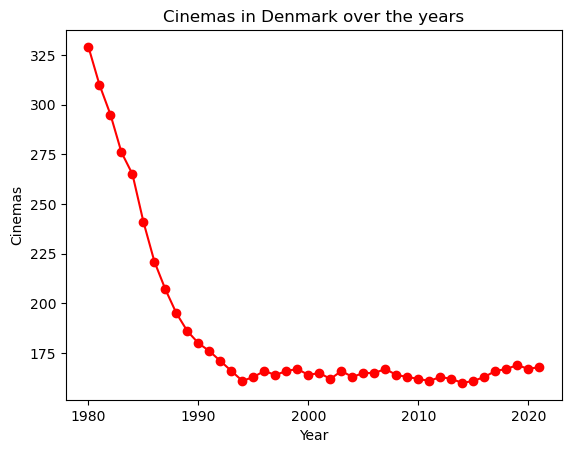

In [4]:
cinema_data.head()
plt.plot(cinema_data["Year"],cinema_data["Cinemas"], color="red", marker="o")
plt.title("Cinemas in Denmark over the years")
plt.xlabel("Year")
plt.ylabel("Cinemas")
plt.show()

## Exercise 2

In this exercise, we are going to use the `penguins` dataset from the Seaborn package. The cell below loads the data

Initial data preparation: Filling or removing missing values

In [5]:
penguins_data = sns.load_dataset("penguins")
penguins_data

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [6]:
penguins_data.info()
#RangeIndex tells us that there are 344 Entries, letting us know that 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g' and 'sex'
#are subject to NA values with sex having the largest amount of NA.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [7]:
#'Whenever possible, it is often preferable to fill in missing values instead of deleting them.' -Missing values and outliers.ipynb
penguins_data.groupby("species")[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]].mean()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.791391,18.346358,189.953642,3700.662252
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.504878,14.982114,217.186992,5076.016260


In [8]:
#Considering that the mean differs based on species the NA values should be filled based on the mean of species.
penguins_data[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]] = penguins_data.groupby("species")[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]].transform(
  lambda x: x.fillna(x.mean())
)

#with sex I can't calculate the mean and filling all the rows seems like a lot for now so I will mark the NA as 'Unknown'
penguins_data["sex"] = penguins_data["sex"].fillna("Unknown")

penguins_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     344 non-null    float64
 3   bill_depth_mm      344 non-null    float64
 4   flipper_length_mm  344 non-null    float64
 5   body_mass_g        344 non-null    float64
 6   sex                344 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


Based on the `Penguins` dataset, answer the following questions:

1. Make a barplot that shows how many penguins there are of each species in the dataset. Support the plot by calculating the numbers.
2. Make a barplot that shows the average body mass for each species of penguin. Support the plot by calculating the numbers
3. Make a boxplots that shows the distribution of the body mass for each species of penguin. Support the plot by calculating the numbers.
4. Make a scatterplot that shows the correlation between body mass (in g) and flipper length (in mm). Support the plot by calculating the numbers.
5. Use boxplots and histograms to show how bill length, bill depth, flipper length and body mass varies between species and sex.
6. Visualise how the linear correlation between body mass and flipper length varies between species and sex.

### 2.1 Make a barplot that shows how many penguins there are of each species in the dataset. Support the plot by calculating the numbers.

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

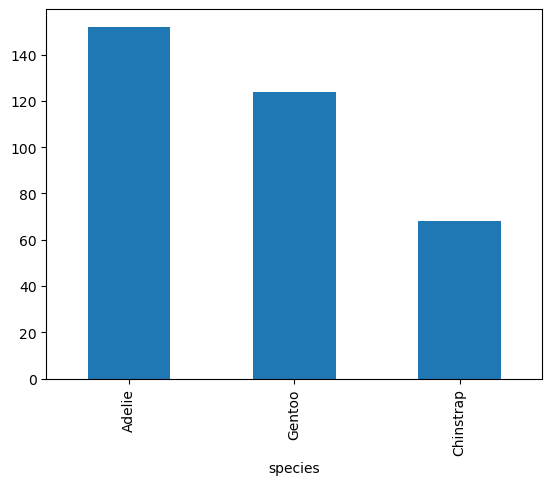

In [9]:
penguins_data["species"].value_counts().plot.bar()
penguins_data["species"].value_counts()

## 2.2 Make a barplot that shows the average body mass for each species of penguin. Support the plot by calculating the numbers

species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64

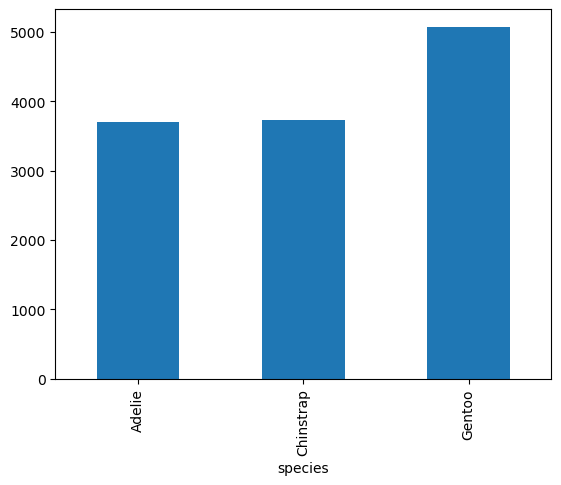

In [10]:
penguins_data.groupby("species")["body_mass_g"].mean().plot.bar()
penguins_data.groupby("species")["body_mass_g"].mean()


## 2.3 Make a boxplots that shows the distribution of the body mass for each species of penguin. Support the plot by calculating the numbers.

In [11]:
penguins_data.groupby("species")["body_mass_g"].describe()

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Adelie,152.0,3700.662252,457.045173,2850.0,3350.0,3700.0,4000.0,4775.0
Chinstrap,68.0,3733.088235,384.335081,2700.0,3487.5,3700.0,3950.0,4800.0
Gentoo,124.0,5076.016260,502.062801,3950.0,4700.0,5025.0,5500.0,6300.0


<Axes: xlabel='species', ylabel='body_mass_g'>

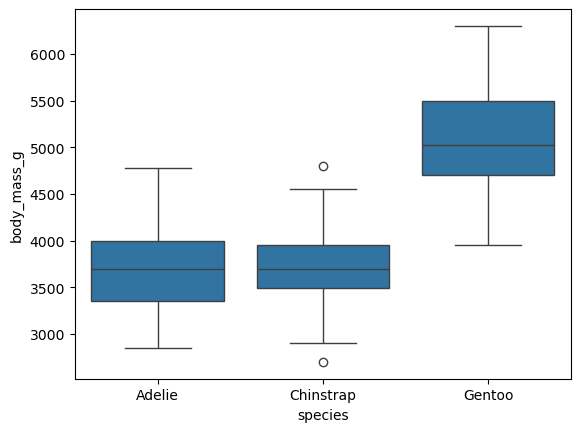

In [12]:
sns.boxplot(x="species", y="body_mass_g", data=penguins_data)

## 2.4 Make a scatterplot that shows the correlation between body mass (in g) and flipper length (in mm). Support the plot by calculating the numbers.

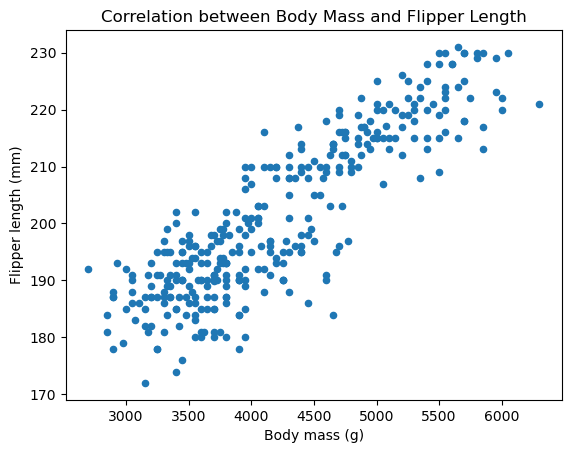

np.float64(0.8718226702185417)

In [13]:
penguins_data.plot.scatter(
    x="body_mass_g",
    y="flipper_length_mm"
)

plt.xlabel("Body mass (g)")
plt.ylabel("Flipper length (mm)")
plt.title("Correlation between Body Mass and Flipper Length")
plt.show()

correlation = penguins_data["body_mass_g"].corr(penguins_data["flipper_length_mm"])
correlation

## 2.5 Use boxplots and histograms to show how bill length, bill depth, flipper length and body mass varies between species and sex.

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

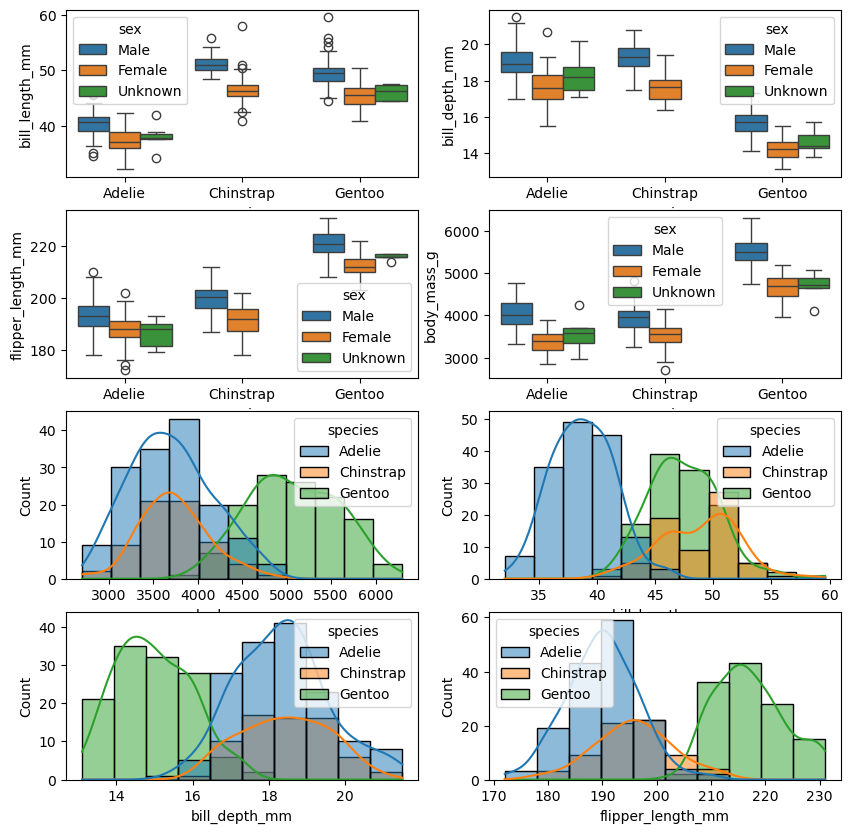

In [29]:
fig, axes = plt.subplots(4, 2, figsize=(10, 10))

sns.boxplot(x='species', y='bill_length_mm', hue='sex', data=penguins_data, ax=axes[0, 0])
sns.boxplot(x='species', y='bill_depth_mm', hue='sex', data=penguins_data, ax=axes[0, 1])
sns.boxplot(x='species', y='flipper_length_mm', hue='sex', data=penguins_data, ax=axes[1, 0])
sns.boxplot(x='species', y='body_mass_g', hue='sex', data=penguins_data, ax=axes[1, 1])

sns.histplot(
    data=penguins_data,
    x="body_mass_g",
    hue="species",
    kde=True,
    ax=axes[2,0]
)

sns.histplot(
    data=penguins_data,
    x="bill_length_mm",
    hue="species",
    kde=True,
    ax=axes[2,1]
)

sns.histplot(
    data=penguins_data,
    x="bill_depth_mm",
    hue="species",
    kde=True,
    ax=axes[3,0]
)

sns.histplot(
    data=penguins_data,
    x="flipper_length_mm",
    hue="species",
    kde=True,
    ax=axes[3,1]
)

## Exercise 3

Do an exploratory data analysis of the adult dataset. The cell below loads the dataset from UCI Machine Learning Repository into a pandas dataframe called `adult_data`. It requires that you have installed the package `ucimlrepo`. (Otherwise the dataset is on moodle page for this class.)

In [30]:
from ucimlrepo import fetch_ucirepo 
adult = fetch_ucirepo(id=2) 
X = adult.data.features 
y = adult.data.targets 
X["income"] = y
adult_data = X.copy()

adult_data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [ ]:
adult_data.info() # column names, types, missing counts
adult_data.head() # peek at actual values
adult_data.shape # how many rows and columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


(48842, 15)

## Exercise 4 (Optional)

Complete an exploratory data analysis of the titanic dataset (it is on moodle). (Remember, you can load it in as `titanic_data = pd.read_csv("titanic_survival_data.csv")`)

## Exercise 5 (Optional)

Do an exploratory data analysis of the diabetes dataset. The cell below loads the dataset from the scikit learn package into the pandas dataframe called `diabetes_data`.

In [40]:
from sklearn.datasets import load_diabetes
d_data = load_diabetes(as_frame=True)
diabetes_data = d_data.data
diabetes_data["Target"] = d_data.target

diabetes_data

ModuleNotFoundError: No module named 'sklearn'